### Normal Guide Generation

In [43]:
import torch
import matplotlib.pyplot as plt
import pickle
import matplotlib.cm as cm
from io import BytesIO
from PIL import Image
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from qwen_vl_utils import process_vision_info
from transformers import Qwen2VLForConditionalGeneration, AutoTokenizer, AutoProcessor
import h5py

In [44]:
os.chdir("..")
print("current path:", os.getcwd())

current path: /home


In [45]:
def show_ts_image(values, labels=[], xlim_arr=[0,1000], ylim_arr=[-1,1], gt=True):
    plt.close()
    plt.figure(figsize=(12, 2))
    plt.plot(
        range(xlim_arr[0], xlim_arr[1]),
        values
    )
    plt.xlim(xlim_arr)
    plt.ylim(ylim_arr)

    anomalies_idx = [xlim_arr[0]+i for i,l in enumerate(labels) if l==1] 
    if gt == True and labels != []:
        plt.bar(anomalies_idx, 2, bottom=ylim_arr[0], width=ylim_arr[1], color='green',alpha=0.5, label='Ground-truth') 

    app_range = (xlim_arr[1]-xlim_arr[0])//5
    xticks = list(range(xlim_arr[0], xlim_arr[1]+1, app_range))
    plt.xticks(xticks)
    plt.xticks(fontsize=20) 
    plt.tight_layout()
    plt.show()

In [46]:
def segment_image_process(values, labels=[], xlim_arr=[0, 1000], ylim_arr=[-1, 1]):
    plt.close()
    plt.figure(figsize=(12, 2))
    plt.plot(
        range(xlim_arr[0], xlim_arr[1]),
        values
    )
    plt.xlim(xlim_arr)
    plt.ylim(ylim_arr)

    app_range = (xlim_arr[1]-xlim_arr[0])//5
    xticks = list(range(xlim_arr[0], xlim_arr[1]+1, app_range))
    plt.xticks(xticks)
    plt.xticks(fontsize=20) 
    plt.tight_layout()

    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=100, bbox_inches='tight') 
    buf.seek(0)
    pil_image = Image.open(buf)
    return pil_image

In [47]:
def pil_show(image):
    plt.close()
    plt.imshow(image)
    plt.axis('off')
    plt.show()

In [48]:
def pil_save(image, file_path):
    plt.close()
    plt.imshow(image)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(file_path, bbox_inches='tight', dpi=100)

In [49]:
def get_data(data_path):
    with open(data_path, 'rb') as f:
        data = pickle.load(f)
        value_list = []
        label_list = []

        data_length = len(data['series'])

        for num in range(data_length):
            org_values = data['series'][num]
            values = [value[0] for value in org_values]

            org_answers = data['anom'][num]
            labels = [0 for _ in range(len(values))]
            for answer in org_answers[0]:
                start, end = answer[0], answer[1] # interval 
                labels[start:end] = [1 for _ in range(start, end)]

            value_list.append(values)
            label_list.append(labels)

    return value_list, label_list

In [50]:
def qwen_make_messages_one_image(prompt, image):
    messages = [
        {
            "role": "system", 
            "content": "You are a time series anomaly detector."
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image,
                },
                {
                    "type": "text", 
                    "text": prompt
                },
            ],
        }
    ]
    return messages

In [51]:
def qwen_inference(model, processor, messages, device='cuda'):
    # Preparation for inference
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = inputs.to(device)

    # Inference: Generation of the output
    generated_ids = model.generate(**inputs, max_new_tokens=128)
    generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    return output_text[0]

In [52]:
def estimate_dominant_period(values):
    time_length = len(values)
    half = len(values) // 2
    fft_result = np.fft.fft(values)
    magnitude = np.abs(fft_result)[:half]
    m_tuple = [(i+1, v) for i, v in enumerate(magnitude[1:])] # [(idx, magnitude), ...]
    sm_tuple = sorted(m_tuple, key=lambda x:x[1])[::-1] # sorted: [(idx, magnitude), ...]
    high_indice = [v[0] for v in sm_tuple] # [idx_1, idx_2, ...]
    period_arr = [round(time_length/i) for i in high_indice] # [period_1, period_2, ...]
    period_arr = [period for period in period_arr if period > 10 ]

    if period_arr[0] == time_length:
        return period_arr[1]
    else:
        return period_arr[0]

In [53]:
def inference(model_set, prompt, image_path, device):
    model = model_set[0]
    processor = model_set[1]
    messages = qwen_make_messages_one_image(prompt, image_path)
    output = qwen_inference(model, processor, messages, device)
    return output

In [54]:
def prompt_selection(period=50):
    prompt = f"""
    The given image shows an example of time series data.  
    The first row represents the trend component, and the second row represents the seasonal component with a period of {period}.  

    Based on the visualized data, analyze the characteristics of the time series and return your answer in the following JSON format.  

    Each field should include:
    - "trend": Description of the trend component
    - "seasonality": Description of the seasonal component and its periodic behavior
    - "shape": Overall shape (e.g., increasing, decreasing, cyclic)
    - "state": Stability of the data (e.g., stable, fluctuating)

    Respond strictly in the following JSON format. Do not provide any additional explanation or comments.

    {{
        "trend": "",
        "seasonality": "",
        "shape": "",
        "state": "",
    }}
    """
    return prompt

In [55]:
qwen_path = "/home/inpyo/inpyo/Code-LMTAD-main/llm_model/Qwen2-VL-7B-Instruct" #qwen 절대경로 입력필요
model = Qwen2VLForConditionalGeneration.from_pretrained(qwen_path, torch_dtype="auto", device_map="auto"
)
processor = AutoProcessor.from_pretrained(qwen_path)

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu and disk.


---

In [56]:
def time_segmentation(values, time_length, period_arr, stride=200):
    all_segment_list = []
    for period in period_arr:
        segment_length = int((time_length-period)/stride)+1
        segment_list = [values[i*stride:i*stride+period] for i in range(0, segment_length)]
        all_segment_list.append(segment_list)
    return all_segment_list

In [57]:
def stl_decompose(data_array, period=100):
    data_array = np.array(data_array)
    stl = STL(data_array, period=period)
    result = stl.fit()

    return result.trend, result.seasonal

In [58]:
def stack_images_vertically(image_list):
    widths, heights = zip(*(img.size for img in image_list))
    max_width = max(widths)
    total_height = sum(heights)
    new_image = Image.new('RGB', (max_width, total_height), (255, 255, 255))
    y_offset = 0
    for img in image_list:
        new_image.paste(img, (0, y_offset))
        y_offset += img.height
    return new_image

---

In [59]:
data_path_list = []
data_path_list.append('/home/inpyo/inpyo/Code-LMTAD-main/data/synthetic/freq/train/data.pkl')
data_path_list.append('/home/inpyo/inpyo/Code-LMTAD-main/data/synthetic/trend/train/data.pkl')
data_path_list.append('/home/inpyo/inpyo/Code-LMTAD-main/data/synthetic/point/train/data.pkl')
data_path_list.append('/home/inpyo/inpyo/Code-LMTAD-main/data/synthetic/range/train/data.pkl')
data_path_list.append('/home/inpyo/inpyo/Code-LMTAD-main/data/synthetic/flat-trend/train/data.pkl')
data_path_list.append('/home/inpyo/inpyo/Code-LMTAD-main/data/synthetic/noisy-freq/train/data.pkl')
data_path_list.append('/home/inpyo/inpyo/Code-LMTAD-main/data/synthetic/noisy-point/train/data.pkl')
data_path_list.append('/home/inpyo/inpyo/Code-LMTAD-main/data/synthetic/noisy-trend/train/data.pkl')

In [60]:
data_type_list = ['freq', 'trend', 'point', 'range', 'flat-trend', 'noisy-freq', 'noisy-point', 'noisy-trend']

In [61]:
key_indice = [39,86,373,165,124,74,246,32]

In [62]:
key_item_list = []
for i, data_path in enumerate(data_path_list):
    value_list, label_list = get_data(data_path)
    k = key_indice[i]
    key_item_list.append((value_list[k], label_list[k]))

In [63]:
work_num = 1

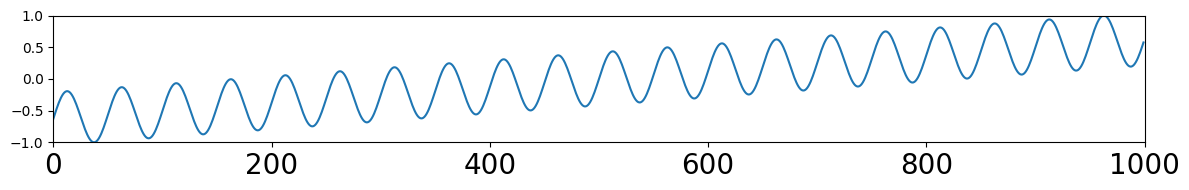

trend
50


In [64]:
key_item = key_item_list[work_num]
key_type = data_type_list[work_num]

key_value = key_item[0]
key_label = key_item[1]
show_ts_image(key_value, key_label)
rep_period = estimate_dominant_period(key_value)

print(key_type)
print(rep_period)

---

0. 시계열 분할 -> STL 분해 및 이미지 제작

In [65]:
period_arr = [i for i in range(50, 1001, 50)]
all_segment_list = time_segmentation(key_value, len(key_value), period_arr)
print(len(all_segment_list))

20


5
5
5
5
4
4
4
4
3
3
3
3
2
2
2
2
1
1
1
1


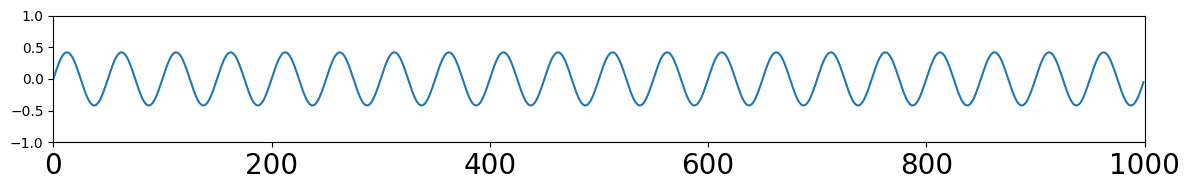

In [66]:
all_total_img_list = []
for segment_list in all_segment_list:
    total_img_list = []
    for sample_item in segment_list:
        trend_arr, seasonal_arr = stl_decompose(sample_item, rep_period)
        trend_img = segment_image_process(values = trend_arr, xlim_arr=[0, len(sample_item)])
        seosonal_img = segment_image_process(values = seasonal_arr, xlim_arr=[0, len(sample_item)])
        total_img = stack_images_vertically([trend_img, seosonal_img])
        total_img_list.append(total_img)
    print(len(total_img_list))
    all_total_img_list.append(total_img_list)

1. description 저장 (normal_guide.json)

In [67]:
prompt = prompt_selection(rep_period)
print(prompt)

all_description_list = []

for total_img_list in all_total_img_list:
    description_list = []
    for total_img in total_img_list:
        messages = qwen_make_messages_one_image(prompt, total_img)
        output = qwen_inference(model, processor, messages)
        description_list.append(output)
    print(len(description_list))
    all_description_list.append(description_list)


    The given image shows an example of time series data.  
    The first row represents the trend component, and the second row represents the seasonal component with a period of 50.  

    Based on the visualized data, analyze the characteristics of the time series and return your answer in the following JSON format.  

    Each field should include:
    - "trend": Description of the trend component
    - "seasonality": Description of the seasonal component and its periodic behavior
    - "shape": Overall shape (e.g., increasing, decreasing, cyclic)
    - "state": Stability of the data (e.g., stable, fluctuating)

    Respond strictly in the following JSON format. Do not provide any additional explanation or comments.

    {
        "trend": "",
        "seasonality": "",
        "shape": "",
        "state": "",
    }
    


/home/inpyo/anaconda3/envs/qwen/lib/python3.10/site-packages/transformers/generation/utils.py:2629: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cuda, whereas the model is on cpu. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cpu') before running `.generate()`.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
file_path = f'Guide/{key_type}/normal_guide.json'

dict_arr = []
with open(file_path, 'w') as file:
    for i, description_list in enumerate(all_description_list):
        # parsed = json.dumps(description_list)
        new_dict = {}
        new_dict["range"] = (i+1)*100
        new_dict["desc"] = description_list

        print(new_dict)
        dict_arr.append(new_dict)
    json.dump(dict_arr, file, indent=4)

2. feature 저장 (normal_feature.h5)

In [ ]:
feature_file_path = f'Guide/{key_type}/normal_feature.h5'

with h5py.File(feature_file_path, 'w') as f:
    for i, segment_list in enumerate(all_segment_list):
        print(i, len(segment_list))
        f.create_dataset(str(i), data=segment_list)

In [ ]:
with h5py.File(feature_file_path, 'r') as all_features:
    for key in all_features:
        features = all_features[key][:]
        print(len(features), features[0].shape)

---

In [ ]:
for work_num in range(len(data_type_list)):
    # class selection
    key_item = key_item_list[work_num]
    key_type = data_type_list[work_num]
    key_value = key_item[0]

    if not os.path.exists(f'Guide/{key_type}/normal_range'):
        os.mkdir(f'Guide/{key_type}/normal_range')

    # calc peiod using ffp
    rep_period = estimate_dominant_period(key_value)

    # time series sementation 
    period_arr = [i for i in range(50, 1001, 50)]
    all_segment_list = time_segmentation(key_value, len(key_value), period_arr)
    print(work_num, key_type, 'time series segmentation ok!')

    # stl decomposition & image generation
    all_total_img_list = []
    for segment_list in all_segment_list:
        total_img_list = []
        segment_length = len(segment_list[0])

        if not os.path.exists(f'Guide/{key_type}/normal_range/{segment_length}'):
            os.mkdir(f'Guide/{key_type}/normal_range/{segment_length}')

        for i, segment in enumerate(segment_list):
            segment_img = segment_image_process(values = segment, xlim_arr=[0, segment_length])
            path = f'Guide/{key_type}/normal_range/{segment_length}/{segment_length}_{i}.png'
            pil_save(segment_img, path)
    print(work_num, key_type, 'image generation ok!')

In [ ]:
for work_num in range(len(data_type_list)):
    # class selection
    key_item = key_item_list[work_num]
    key_type = data_type_list[work_num]
    key_value = key_item[0]

    # calc peiod using ffp
    rep_period = estimate_dominant_period(key_value)

    # time series sementation 
    period_arr = [i for i in range(50, 1001, 50)]
    all_segment_list = time_segmentation(key_value, len(key_value), period_arr)
    print(work_num, key_type, 'time series segmentation ok!')

    # stl decomposition & image generation
    all_total_img_list = []
    for segment_list in all_segment_list:
        total_img_list = []
        for sample_item in segment_list:
            trend_arr, seasonal_arr = stl_decompose(sample_item, rep_period)
            trend_img = segment_image_process(values = trend_arr, xlim_arr=[0, len(sample_item)])
            seosonal_img = segment_image_process(values = seasonal_arr, xlim_arr=[0, len(sample_item)])
            total_img = stack_images_vertically([trend_img, seosonal_img])
            total_img_list.append(total_img)
        all_total_img_list.append(total_img_list)
    print(work_num, key_type, 'stl based image generation ok!')

    # captioning per normal segment 
    prompt = prompt_selection(rep_period)
    all_description_list = []

    for total_img_list in all_total_img_list:
        description_list = []
        for total_img in total_img_list:
            messages = qwen_make_messages_one_image(prompt, total_img)
            output = qwen_inference(model, processor, messages)
            description_list.append(output)
        all_description_list.append(description_list)
    print(work_num, key_type, 'captioning ok!')

    # save all captions
    file_path = f'Guide/{key_type}/normal_guide.json'
    dict_arr = []
    with open(file_path, 'w') as file:
        for i, description_list in enumerate(all_description_list):
            new_dict = {}
            new_dict["range"] = (i+1)*50
            new_dict["desc"] = description_list
            dict_arr.append(new_dict)
        json.dump(dict_arr, file, indent=4)
    print(work_num, key_type, 'save all captions ok!')

    # save all features
    feature_file_path = f'Guide/{key_type}/normal_feature.h5'

    with h5py.File(feature_file_path, 'w') as f:
        for i, segment_list in enumerate(all_segment_list):
            f.create_dataset(str(i), data=segment_list)
    print(work_num, key_type, 'save all features ok!')